In [1]:
from __future__ import division
import json
%matplotlib inline
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
import itertools, operator
import csv
import os,glob
import datetime
import geopandas as gpd
from shapely import wkt
from scipy.stats import linregress, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point


import networkx as nx
import collections

from scipy.stats import gaussian_kde

from scipy.spatial import cKDTree

import os
import sys

# INFORMATION

In [2]:
date = '_07_2023'

# COLORS

In [3]:
colors_income = ['#FCBF49','#F77F00','#D62828'] #low, medium, high
colors_gender = ['#7209B7','#4CC9F0'] #fem, mal
colors_age = ['#BE95C4','#9F86C0','#5E548E','#231942'] #young->old

In [4]:
from matplotlib.colors import LinearSegmentedColormap
cmap_income = LinearSegmentedColormap.from_list('income', colors_income)
cmap_gender = LinearSegmentedColormap.from_list('gender', colors_gender)
cmap_age = LinearSegmentedColormap.from_list('age', colors_age)

# CITIES

In [26]:
cities = ['Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Zaragoza', 'Malaga', 'Murcia', 'Palma_de_Mallorca', 'Las_Palmas',
          'Alicante', 'Bilbao', 'Valladolid', 'Cordoba', 'Vigo', 'Gijon', 'Vitoria_Gasteiz', 'A_Coruna', 'Granada', 'Elche', 
          'Cartagena', 'Oviedo', 'Jerez_de_la_Frontera', 'Santa_Cruz_de_Tenerife']

In [5]:
cities = ['Tarragona','Castellon','Santander','Pamplona','Almeria','San_Sebastian']

# OPEN DISTRICTS DATA

In [6]:
# only OUR DISTRICTS

os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\DATA\districts')

results_districts = pd.read_csv('results_districts'+date+'.csv')

In [7]:
mask = results_districts['geometry'].apply(lambda x: isinstance(x, str))
if mask.any():
    results_districts.loc[mask, 'geometry'] = results_districts.loc[mask, 'geometry'].apply(wkt.loads)

results_districts = gpd.GeoDataFrame(results_districts, geometry='geometry')

print("Current CRS:", results_districts.crs)

results_districts.set_crs(epsg='25830', inplace=True) 

results_districts['centroid'] = results_districts.geometry.centroid

results_districts['x'] = results_districts.centroid.x
results_districts['y'] = results_districts.centroid.y

results_districts = results_districts.drop(columns=['centroid'])

print(results_districts[['geometry', 'x', 'y']].head())

Current CRS: None
                                            geometry              x  \
0  MULTIPOLYGON (((538090.184 4737372.731, 537856...  539945.693847   
1  MULTIPOLYGON (((501984.889 4753913.87, 501945....  502306.663426   
2  MULTIPOLYGON (((488613.969 4778775.797, 488800...  493797.445729   
3  POLYGON ((554658.552 4740793.546, 554617.177 4...  546467.060711   
4  POLYGON ((499938.436 4768365.76, 499305.175 47...  493632.646513   

              y  
0  4.741949e+06  
1  4.763643e+06  
2  4.777479e+06  
3  4.747997e+06  
4  4.769208e+06  


In [8]:
grouped = results_districts.groupby('city')

results_districts = {city: group.copy() for city, group in grouped}

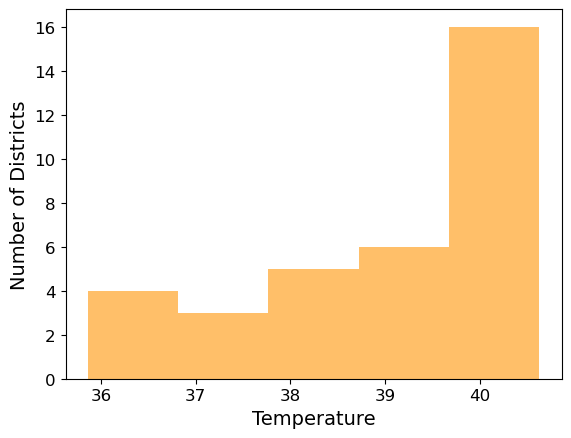

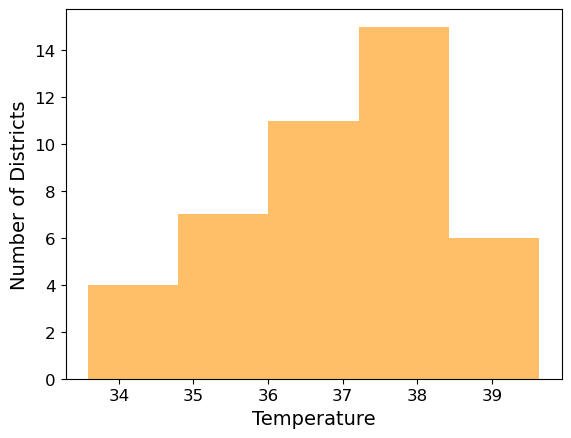

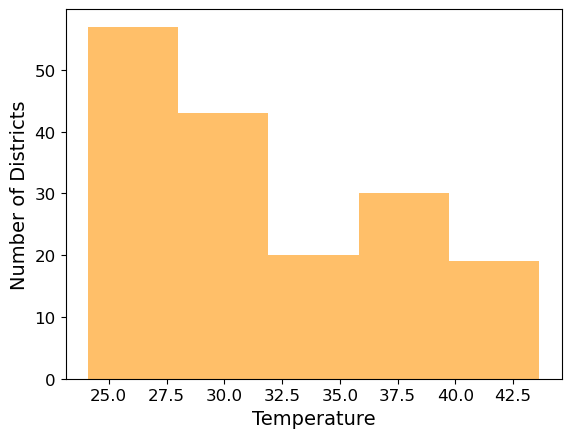

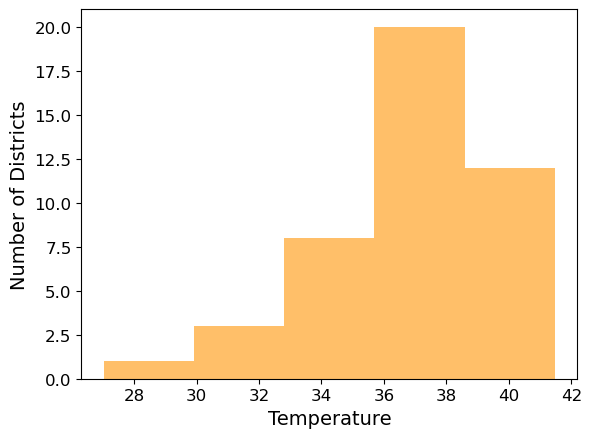

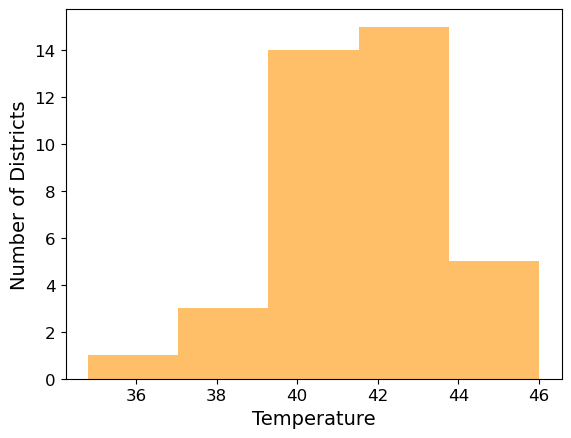

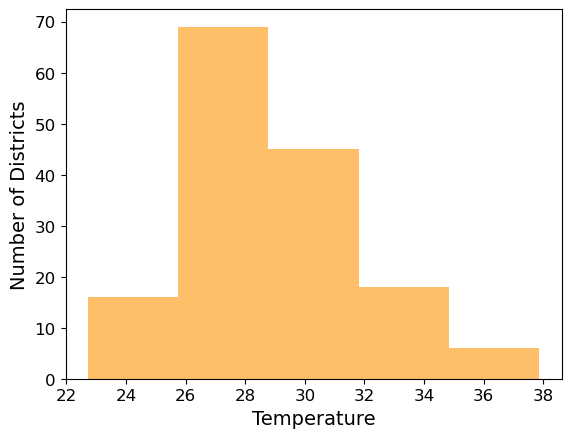

In [9]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\DATA')

# 1) Plot histograms for each city
for city in cities:
    df_city = results_districts[city]
    
    # Plot avg_T
    plt.hist(df_city['avg_T'], bins=5, color='#ffbf69')
    # plt.title(f"{city} - Histogram of avg_T")
    plt.xlabel("Temperature", fontsize=14)
    plt.ylabel("Number of Districts", fontsize=14)
    plt.tick_params(axis='x', labelsize=12) 
    plt.tick_params(axis='y', labelsize=12) 
    # plt.savefig(city + 'T_districts_histogram.svg', format='svg', dpi=600, bbox_inches='tight')
    plt.show()

# OPEN MOBILITY DATA

In [10]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2')

mob =  pd.read_csv('mob_daily'+date+'.csv', dtype={'origen': str, 'destino': str})

In [11]:
mob

,origen,destino,actividad_origen,actividad_destino,renta,edad,day,viajes,x_orig,y_orig,x_dest,y_dest,distance
0,01001,01001,casa,frecuente,10-15,0-25,3,38.308,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.000000
1,01001,01001,casa,frecuente,10-15,0-25,27,32.616,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.000000
2,01001,01001,casa,frecuente,10-15,0-25,31,26.930,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.000000
3,01001,01001,casa,trabajo_estudio,10-15,0-25,2,29.756,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.000000
4,01001,01001,casa,trabajo_estudio,10-15,0-25,7,42.400,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10107109,FRI15,48912_AM,no_frecuente,no_frecuente,10-15,65-100,11,3.628,681684.497242,4.791757e+06,495968.942921,4.782036e+06,185969.786893
10107110,FRI15,48912_AM,no_frecuente,no_frecuente,>15,0-25,22,4.076,681684.497242,4.791757e+06,495968.942921,4.782036e+06,185969.786893
10107111,FRI15,48912_AM,no_frecuente,no_frecuente,>15,0-25,28,2.000,681684.497242,4.791757e+06,495968.942921,4.782036e+06,185969.786893
10107112,FRI15,FRI15,frecuente,trabajo_estudio,10-15,45-65,21,6.300,681684.497242,4.791757e+06,681684.497242,4.791757e+06,0.000000


In [12]:
print("ANTES")
mob.info(memory_usage='deep')

obj_cols = mob.select_dtypes(include=['object']).columns.tolist()
print("Columnas object:", obj_cols)

for col in obj_cols:
    print(col, "→", mob[col].nunique(), "valores únicos")

to_cat = ['origen','destino','actividad_origen','actividad_destino','renta','edad']
for col in to_cat:
    mob[col] = mob[col].astype('category')
     
print("\nDESPUÉS")
mob.info(memory_usage='deep')

ANTES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10107114 entries, 0 to 10107113
Data columns (total 13 columns):
 #   Column             Dtype  
---  ------             -----  
 0   origen             object 
 1   destino            object 
 2   actividad_origen   object 
 3   actividad_destino  object 
 4   renta              object 
 5   edad               object 
 6   day                int64  
 7   viajes             float64
 8   x_orig             float64
 9   y_orig             float64
 10  x_dest             float64
 11  y_dest             float64
 12  distance           float64
dtypes: float64(6), int64(1), object(6)
memory usage: 3.7 GB
Columnas object: ['origen', 'destino', 'actividad_origen', 'actividad_destino', 'renta', 'edad']
origen → 473 valores únicos
destino → 473 valores únicos
actividad_origen → 4 valores únicos
actividad_destino → 4 valores únicos
renta → 3 valores únicos
edad → 4 valores únicos

DESPUÉS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101

In [13]:
mob['actividad_destino'].unique()

['frecuente', 'trabajo_estudio', 'casa', 'no_frecuente']
Categories (4, object): ['casa', 'frecuente', 'no_frecuente', 'trabajo_estudio']

# MERGE BOTH DISTRICT DATA WITH MOBILITY DATA

In [14]:
metrics_cols = ['ID', 'avg_T', 'median_revenue_per_consumption', 'population']

In [15]:
origen_cols = {}

for city in cities:
    origen_cols[city] = results_districts[city][metrics_cols].rename(
        columns={
            'ID': 'origen_ID',
            'avg_T': 'avg_T_origen',
            'median_revenue_per_consumption': 'median_income_per_consumption_origen',
            'population': 'population_origen'
        }
    )

In [16]:
destino_cols = {}

for city in cities:
    destino_cols[city] = results_districts[city][metrics_cols].rename(
        columns={
            'ID': 'destino_ID',
            'avg_T': 'avg_T_destino',
            'median_revenue_per_consumption': 'median_income_per_consumption_destino',
            'population': 'population_destino'
        }
    )

In [17]:
mob['origen'] = mob['origen'].astype(str).str.strip()

for city in cities:
    
    origen_cols[city]['origen_ID'] = origen_cols[city]['origen_ID'].astype(str).str.strip()
    destino_cols[city]['destino_ID'] = destino_cols[city]['destino_ID'].astype(str).str.strip()

In [18]:
to_obj = ['origen','destino',
          'actividad_origen','actividad_destino',
          'renta','edad']
mobs = {}

for city in cities:
    df = mob.copy()

    df = df.merge(
        origen_cols[city],
        left_on='origen', right_on='origen_ID',
        how='left'
    ).drop('origen_ID', axis=1).dropna(subset=[
         'avg_T_origen',
         'median_income_per_consumption_origen', 'population_origen'
     ])

    df = df.merge(
        destino_cols[city],
        left_on='destino', right_on='destino_ID',
        how='left'
    ).drop('destino_ID', axis=1).dropna(subset=[
         'avg_T_destino',
         'median_income_per_consumption_destino', 'population_destino'
     ])

    df[to_cat] = df[to_obj].astype('object')

    mobs[city] = df

In [19]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\DATA')

for city in cities:
    
    mobs[city].to_csv(city +'_mob_daily'+date+'.csv', index=False)

In [20]:
mobs[city]

,origen,destino,actividad_origen,actividad_destino,renta,edad,day,viajes,x_orig,y_orig,x_dest,y_dest,distance,avg_T_origen,median_income_per_consumption_origen,population_origen,avg_T_destino,median_income_per_consumption_destino,population_destino
0,01001,01001,casa,frecuente,10-15,0-25,3,38.308,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.0,32.397593,20.65,2925.0,32.397593,20.65,2925.0
1,01001,01001,casa,frecuente,10-15,0-25,27,32.616,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.0,32.397593,20.65,2925.0,32.397593,20.65,2925.0
2,01001,01001,casa,frecuente,10-15,0-25,31,26.930,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.0,32.397593,20.65,2925.0,32.397593,20.65,2925.0
3,01001,01001,casa,trabajo_estudio,10-15,0-25,2,29.756,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.0,32.397593,20.65,2925.0,32.397593,20.65,2925.0
4,01001,01001,casa,trabajo_estudio,10-15,0-25,7,42.400,539945.693847,4.741949e+06,539945.693847,4.741949e+06,0.0,32.397593,20.65,2925.0,32.397593,20.65,2925.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4322578,48912_AM,48912_AM,trabajo_estudio,no_frecuente,>15,25-45,25,4.540,495968.942921,4.782036e+06,495968.942921,4.782036e+06,0.0,27.382216,22.05,4667.0,27.382216,22.05,4667.0
4322579,48912_AM,48912_AM,trabajo_estudio,no_frecuente,>15,45-65,4,5.968,495968.942921,4.782036e+06,495968.942921,4.782036e+06,0.0,27.382216,22.05,4667.0,27.382216,22.05,4667.0
4322580,48912_AM,48912_AM,trabajo_estudio,no_frecuente,>15,45-65,12,7.348,495968.942921,4.782036e+06,495968.942921,4.782036e+06,0.0,27.382216,22.05,4667.0,27.382216,22.05,4667.0
4322581,48912_AM,48912_AM,trabajo_estudio,no_frecuente,>15,45-65,27,7.764,495968.942921,4.782036e+06,495968.942921,4.782036e+06,0.0,27.382216,22.05,4667.0,27.382216,22.05,4667.0


In [21]:
cities

['Tarragona', 'Castellon', 'Santander', 'Pamplona', 'Almeria', 'San_Sebastian']

In [22]:
mobs

{'Tarragona':        origen destino actividad_origen actividad_destino renta    edad  day  \
 78      43012   43012             casa         frecuente   >15    0-25    4   
 79      43012   43012             casa         frecuente   >15    0-25   10   
 80      43012   43012             casa         frecuente   >15    0-25   28   
 81      43012   43012             casa         frecuente   >15   25-45    4   
 82      43012   43012             casa         frecuente   >15   45-65    4   
 ...       ...     ...              ...               ...   ...     ...  ...   
 738832  43907   43907  trabajo_estudio      no_frecuente   >15  65-100    6   
 738833  43907   43907  trabajo_estudio      no_frecuente   >15  65-100   10   
 738834  43907   43907  trabajo_estudio      no_frecuente   >15  65-100   14   
 738835  43907   43907  trabajo_estudio      no_frecuente   >15  65-100   28   
 738836  43907   43907  trabajo_estudio      no_frecuente   >15  65-100   31   
 
          viajes         